In [ ]:
from pSAT_problem import SATProblem

assignment = 'assignment_T24'
cnf_file_name = 'E:\Aron\BMW_SAT\\bmw_problems\\' + assignment + '.cnf'
myProblem = SATProblem(cnf_file_name)
result = myProblem.verify('E:\Aron\BMW_SAT\\bmw_sol\\solution_T24_r.out')


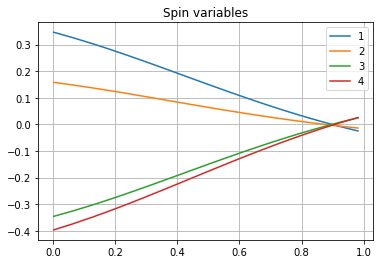

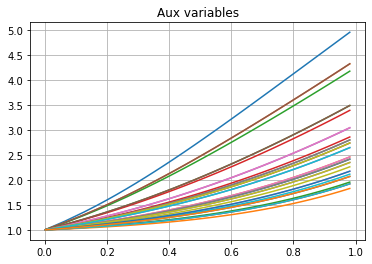

In [4]:
from pSAT_problem import CTDSolver, SATProblem, RK4

#cnf_file_name = 'E:\SAT_project\easy2.cnf'
cnf_file_name = "E:\SAT_project\pySAT\easy_max_sat3_n4.cnf"
#sol = [False, False, True, True, True,True, True, True,True, True, False, False]

myProblem = SATProblem(cnf_file_name)
mIntegrator = RK4()


solver = CTDSolver(myProblem, mIntegrator)
solver.solve(max_time=1)
solver.plot_traj()
solver.plot_aux()

In [ ]:
import itertools

clause_length = 3
number_of_variables = 5

clauses_ = []
for subset in itertools.combinations(range(1,2*number_of_variables+1), clause_length):

    m_str = ""
    for elem in subset:
        if elem > 0 and elem <= number_of_variables:
            m_str += str(elem) + ' '
        elif elem > number_of_variables:
            m_str += str((number_of_variables)-elem) + ' '
            pass
        if elem == 0:
            m_str += str(-number_of_variables) + ' '
    m_str += '0\n'
    clauses_.append(m_str)

with open("easy_full_sat" + str(clause_length) +"_n"+str(number_of_variables)+".cnf", 'w') as file:
    file.write("p cnf " + str(number_of_variables) + " " + str(len(clauses_))+ "\n")
    file.writelines(clauses_)


In [ ]:
import itertools

clause_length = 3
number_of_variables = 4
number_of_clauses = 0

clauses = ""
for subset in itertools.combinations(range(1,2*number_of_variables+1), clause_length):
    clause = []
    for elem in subset:
        if elem > number_of_variables:
            clause.append(-elem+number_of_variables)
        else:
            clause.append(elem)
    valid = True
    for elem in clause:#not allowing both negated and non-negated to appear
        if elem in clause and -elem in clause:
            valid = False
    if valid:
        mstr = ""
        for element in clause:
            mstr += str(element) + " "
        mstr += "0\n"
        clauses += mstr
        number_of_clauses += 1

with open("easy_max_sat" + str(clause_length) +"_n"+str(number_of_variables)+".cnf", 'w') as file:
    file.write("p cnf " + str(number_of_variables) + " " + str(number_of_clauses)+ "\n")
    file.writelines(clauses)